In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [36]:
df = pd.read_csv("/content/loan_approval_dataset.csv")

df.columns = df.columns.str.strip()

df = df.drop(columns=['loan_id'])

In [37]:
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,1
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,0


In [38]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid= GridSearchCV(DecisionTreeClassifier(random_state=42),
                      param_grid={
                          "criterion":["gini","entropy"],
                          "splitter":["best","random"],
                          "max_depth":[3,4,5,6,8,None],
                          "min_samples_leaf" :[1,2,5,10]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1)
dt_grid.fit(X_train,y_train)
dt=dt_grid.best_estimator_
dt_pred = dt_grid.predict(X_test)
print("En iyi parametre:", dt_grid.best_params_)

En iyi parametre: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5, 'splitter': 'best'}


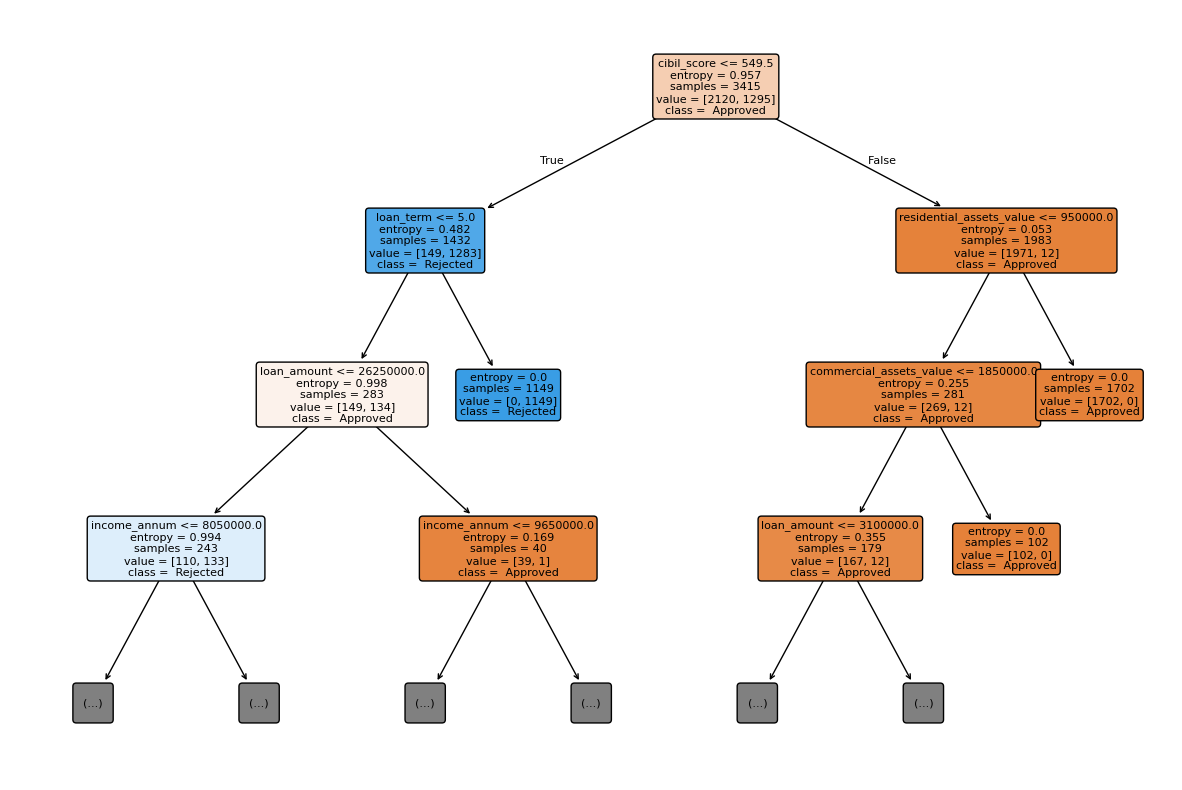

In [39]:
plt.figure(figsize=(15,10))
plot_tree(dt,
          feature_names=list(X.columns),
          class_names=le.classes_,
          filled=True,rounded= True, max_depth= 3, fontsize =8)

plt.show()

In [40]:
dt_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Accuracy:", dt_acc)
print("Precision:", dt_prec)
print("Recall:", dt_rec)
print("F1 Score:", dt_f1)

Accuracy: 0.9824355971896955
Precision: 0.9779179810725552
Recall: 0.9748427672955975
F1 Score: 0.9763779527559056


In [41]:
print(classification_report(y_test, dt_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    Approved       0.99      0.99      0.99       536
    Rejected       0.98      0.97      0.98       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [42]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [43]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1 Score:", rf_f1)

Accuracy: 0.977751756440281
Precision: 0.9776357827476039
Recall: 0.9622641509433962
F1 Score: 0.9698890649762282


In [44]:
X_kmeans = df.drop(columns=['loan_status'])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_kmeans)

print(df['cluster'].value_counts())

cluster
0    2201
1    2068
Name: count, dtype: int64


In [45]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhoutte skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')

En iyi silhoutte skoru: 0.2475
Optimum K degeri: 2


In [46]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [47]:
print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 2
Silhouette Skoru: 0.2475
Davies-Bouldin Indeksi: 1.5183
Calinski-Harabasz Skoru: 1801.1100

Kume dagilimi:
0    2160
1    2109
Name: count, dtype: int64
